# Base model — LSTM on NFv2-CIC-2018

**Original execution record.** Hyperband tuning (learning rate, batch size) followed by 30 epochs of training with a `val_loss` checkpoint. This run produced `models/LSTM_NFv2-CIC-2018_model.keras`, `results/base_models/training_history/LSTM_NFv2-CIC-2018.csv` (parsed from the training log below) and the test metrics in `results/base_models/test_metrics.csv`. Paths refer to the original machine (`/opt/flids`).

Notes: plot cells that did not show the recorded tuning scores and training history were removed (use `scripts/plot_base_results.py` instead). The checkpoint path used the model object instead of the architecture name, so the saved file was renamed to `LSTM_NFv2-CIC-2018_model.keras` afterwards. To re-run, use `python scripts/train_base_models.py --arch LSTM --dataset NFv2-CIC-2018`.

In [1]:
import os
import pandas as pd
import numpy as np
# Base directory
base_dir = '/opt/flids/data/processed'

# Dataset file paths
datasets = {
    'NFv2-CIC-2018': os.path.join(base_dir, 'NF-CSE-CIC-IDS2018-v2_processed.csv'),
}


In [2]:
for name, path in datasets.items():
    try:
        # Load the dataset
        df = pd.read_csv(path)
        # Display the value counts for the 'Attack' column
        print(f"Value counts for dataset {name}:")
        print(df['Attack'].value_counts())
        print("\n")
    except Exception as e:
        print(f"Error processing {name}: {e}")

Value counts for dataset NFv2-CIC-2018:
Attack
DoS       483999
Benign    483993
Name: count, dtype: int64




In [3]:
df.drop(columns=['Attack', 'Label'], inplace=True)
print("shape of dataset（Number of rows, number of columns）:", df.shape)

shape of dataset（Number of rows, number of columns）: (967992, 39)


In [4]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Reshape, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns
# ========== 1. Paths and variables ==========
# Base path and datasets
BASE_DIR = '/opt/flids/data/processed'
DATASETS = {
    'NFv2-CIC-2018': os.path.join(BASE_DIR, 'NF-CSE-CIC-IDS2018-v2_processed.csv'),
}
model = "LSTM"
dataset_name = 'NFv2-CIC-2018'
dataset_path = os.path.join(BASE_DIR, 'NF-CSE-CIC-IDS2018-v2_processed.csv')

# Model output directory
MODEL_DIR = "/opt/flids/tf/models/base/hyperparameter-tuning"
os.makedirs(MODEL_DIR, exist_ok=True)

# Data dump directory
SAVE_DIR = "/opt/flids/data/dump"
os.makedirs(SAVE_DIR, exist_ok=True)

# Define the save directory
image_dir = "/opt/flids/tf/images/base"
os.makedirs(image_dir, exist_ok=True)

tuner_project="lstm_cic_hyperparameter_tuning"
# Scaler
scaler = QuantileTransformer(output_distribution='normal')

2025-03-05 12:03:56.945317: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-05 12:03:56.962724: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-05 12:03:56.967870: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-05 12:03:56.981778: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-05 12:03:57.971677: W tensorflow/comp

In [5]:

# ==================== 1. Define Custom HyperModel with Tunable Batch Size ====================
class MyHyperModel(kt.HyperModel):
    def build(self, hp):
        inputs = Input(shape=(39,), name="LSTM_reshape_input")

        # Reshape layer
        x = Reshape(target_shape=(1, 39), name="lstm_reshape_layer")(inputs)

        # LSTM layers
        x = LSTM(24, activation='relu', return_sequences=True, name="lstm_layer_1")(x)
        x = LSTM(16, activation='relu', return_sequences=False, name="lstm_layer_2")(x)

        # Fully Connected Layer
        x = Dense(8, activation='relu', name="lstm_dense")(x)

        # Output Layer
        outputs = Dense(1, activation='sigmoid', name="lstm_output_layer")(x)

        # Define Model
        model = Model(inputs=inputs, outputs=outputs, name="Custom_LSTM_Model")

        # Hyperparameter Tuning Options
        learning_rate = hp.Choice('learning_rate', values=[0.0001, 0.001, 0.01])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

        return model

    def fit(self, hp, model, *args, **kwargs):
        """Include batch_size in the tuning process"""
        return model.fit(
            *args,
            batch_size=hp.Choice("batch_size", values=[32, 64, 128, 256]),
            **kwargs,
        )

# ==================== 2. Hyperparameter Tuning with Hyperband ====================
def tune_hyperparameters(X_train_scaled, y_train, X_val_scaled, y_val):
    tuner = kt.Hyperband(
        MyHyperModel(),
        objective="val_accuracy",
        max_epochs=30,
        factor=3,  # Reduces the number of trials over time
        directory='tuning_results',
        project_name=tuner_project
    )

    # Perform Search
    tuner.search(X_train_scaled, y_train,
                 validation_data=(X_val_scaled, y_val),
                 epochs=30)

    # Get best hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    return best_hps

# ==================== 3. Train and Evaluate Model ====================
def train_and_evaluate(best_hps, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, dataset_name):
    model = MyHyperModel().build(best_hps)
    model_path = os.path.join(MODEL_DIR, f"{model}_{dataset_name}_model.keras")
    checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)

    # Retrieve best hyperparameters
    print(best_hps.values)
    batch_size = best_hps.values.get('batch_size', 64)  # Batch size is now properly included!

    history = model.fit(
        X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
        epochs=30, batch_size=batch_size, callbacks=[checkpoint]
    )

    print(f"Best model saved to: {model_path}")
    y_test_pred = (model.predict(X_test_scaled) > 0.5).astype(int).flatten()
    return history, y_test_pred

In [6]:
# ==================== 4. Loop through Datasets and Train ====================
try:
    df = pd.read_csv(dataset_path)
    X = df.iloc[:, :-2]  # Features
    y = df.iloc[:, -2]   # Labels

    # Data Splitting
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, stratify=y, test_size=0.1, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, stratify=y_train_val, test_size=0.2, random_state=42)

    # Data Scaling
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Tune Hyperparameters
    best_hps = tune_hyperparameters(X_train_scaled, y_train, X_val_scaled, y_val)

except Exception as e:
    print(f"Error processing {dataset_name}: {e}")

Trial 12 Complete [00h 00m 22s]
val_accuracy: 0.9995638132095337

Best val_accuracy So Far: 0.9999311566352844
Total elapsed time: 00h 12m 34s


In [7]:
# Train Model
try:
    history, y_test_pred = train_and_evaluate(best_hps, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, dataset_name)
except Exception as e:
    print(f"Error processing {dataset_name}: {e}")

{'learning_rate': 0.001, 'batch_size': 256, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 3, 'tuner/round': 0}
Epoch 1/30
2723/2723 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9876 - loss: 0.0467
Epoch 1: val_loss improved from inf to 0.00101, saving model to /opt/flids/tf/models/base/hyperparameter-tuning/<Functional name=Custom_LSTM_Model, built=True>_NFv2-CIC-2018_model.keras
2723/2723 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9876 - loss: 0.0467 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 2/30
2720/2723 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9998 - loss: 7.1084e-04
Epoch 2: val_loss improved from 0.00101 to 0.00043, saving model to /opt/flids/tf/models/base/hyperparameter-tuning/<Functional name=Custom_LSTM_Model, built=True>_NFv2-CIC-2018_model.keras
2723/2723 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9998 - loss: 7.1084e-04 - val_accuracy: 0.9999 - val_loss: 4.2691e-04
Epoch 3/30
2711/2723 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9

Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
False Positive Rate (FPR): 0.0000


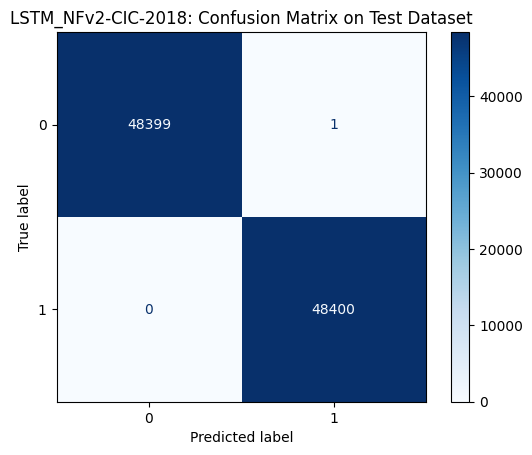

In [8]:
# Evaluate Model
try:
    # Confusion Matrix
    image_dir = "/opt/flids/tf/images/base/evaluation"
    save_path = os.path.join(image_dir, f"{model}_{dataset_name}_Confusion_Matrix.png")
    
    cm = confusion_matrix(y_test, y_test_pred)

    # Compute evaluation metrics
    precision = precision_score(y_test, y_test_pred, average='binary')
    recall = recall_score(y_test, y_test_pred, average='binary')
    f1 = f1_score(y_test, y_test_pred, average='binary')

    # Compute false positive rate (FPR)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # Avoid division by zero

    # Display results
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{model}_{dataset_name}: Confusion Matrix on Test Dataset")
    plt.savefig(save_path, dpi=600)
    plt.show()
    
except Exception as e:
    print(f"Error processing {dataset_name}: {e}")